11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8625 - loss: 0.4738
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9551 - loss: 0.1480
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9682 - loss: 0.1068
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9739 - loss: 0.0882
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9774 - loss: 0.0727
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.0839
Test accuracy: 0.9783999919891357
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


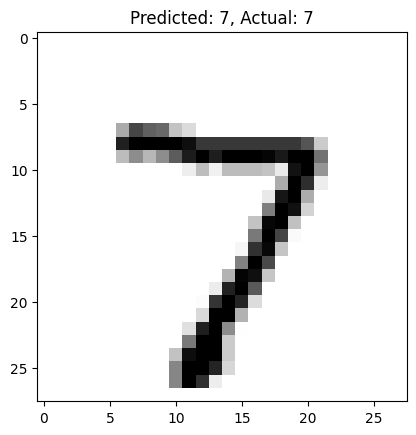

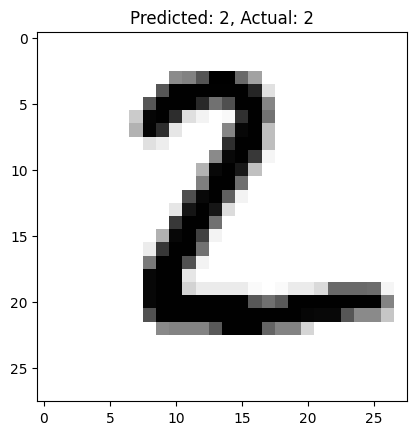

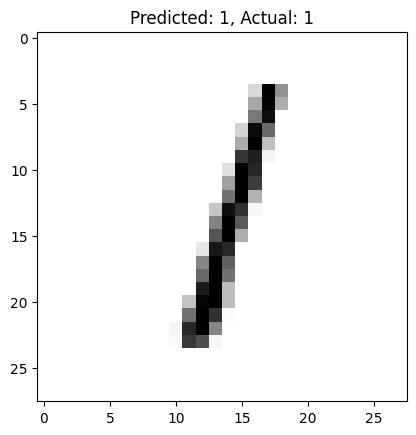

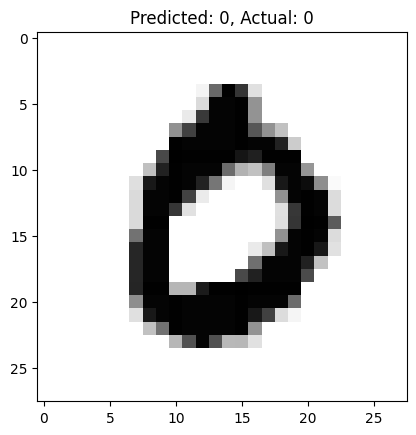

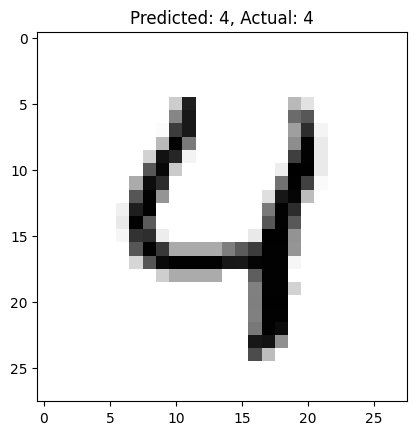

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the data to [0, 1] by dividing by 255
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape data to fit the model's input requirements (28x28 pixels to a flat vector)
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

# Build the model
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(28 * 28,)),  # Hidden layer with 128 neurons
    layers.Dropout(0.2),  # Dropout to prevent overfitting
    layers.Dense(10, activation='softmax')  # Output layer with 10 neurons (one for each digit)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5)

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

# Make predictions on the test data
predictions = model.predict(x_test)

# Plot some test images and their predicted labels
for i in range(5):
    plt.imshow(x_test[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Predicted: {predictions[i].argmax()}, Actual: {y_test[i]}")
    plt.show()
